In [1]:
import sys
sys.path.append('../utils/')
from utils_models import *

In [2]:
max_ql = 30
max_ol = 75
EJ = 3
EC = EJ/4
EL = EJ/20.5
Er = 8.46111172

g = 0.2
w_d = 8.460155465243822
amp = 0.003

tot_time =920
tlist = np.linspace(0, tot_time, tot_time)
system  =  FluxoniumOscillatorSystem(
                EJ = EJ,
                EC = EC,
                EL = EL,
                Er = Er,
                g_strength = g,
                qubit_level = max_ql,
                osc_level = max_ol,
                products_to_keep=[[ql, ol] for ql in [0, 7] for ol in range(max_ol) ],
                computaional_states = '1,2',
                )

In [3]:
with open('sesolve_large_dim_a003.pkl', 'rb') as file:
    results = pickle.load(file)

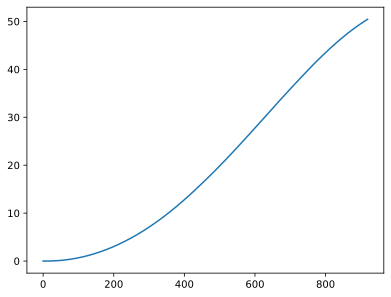

In [4]:
plt.plot(results[0].expect[1])

In [4]:
lists = []
for ql in [0 ]:
    pop_list = []
    for t_idx in tqdm(range(len(tlist))[::10], desc = "t loop"):
        dm = results[ql].states[t_idx]
        pop_sum = 1
        for q in range(15):
            if q == ql:
                for o in range(max_ol):
                    product_state = (q, o)
                    dressed_state = system.product_to_dressed[product_state]
                    basis_state = system.truncate_function(qutip.basis(max_ql * max_ol,  dressed_state))
                    expectation_value = qutip.expect(basis_state * basis_state.dag(), dm)
                    pop_sum -= expectation_value

        pop_list.append(pop_sum)
    lists.append(pop_list)


t loop: 100%|██████████| 92/92 [00:18<00:00,  5.01it/s]


In [5]:
with open('sesolve_large_dim_outside_ori_ladder_list_g0.2a003.pkl', 'wb') as file:
    pickle.dump(lists, file)

Text(0.5, 0, 't (ns)')

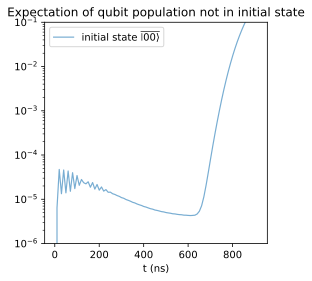

In [6]:
from utils_models import *
plt.figure(figsize=(4,4))
for ql,pop_list in enumerate(lists): 
    plt.plot(tlist[::10],pop_list,label = rf"initial state $\overline{{\left|{ql}0\right>}}$",linewidth =1.2,alpha = 0.6)
plt.yscale('log')
plt.ylim(1e-6,1e-1)
plt.legend()
# plt.title('expecation of qubit not being in initial state,\n sesolve with 15 level qbt, 40 level osc')
plt.title('Expectation of qubit population not in initial state')
plt.xlabel('t (ns)')

Text(0.5, 0, 't (ns)')

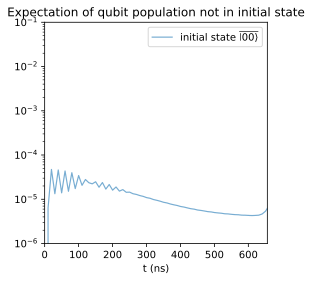

In [7]:
from utils_models import *
plt.figure(figsize=(4,4))
for ql,pop_list in enumerate(lists): 
    plt.plot(tlist[::10],pop_list,label = rf"initial state $\overline{{\left|{ql}0\right>}}$",linewidth =1.2,alpha = 0.6)
plt.yscale('log')
plt.ylim(1e-6,1e-1)
plt.xlim(0,656)
plt.legend()
# plt.title('expecation of qubit not being in initial state,\n sesolve with 15 level qbt, 40 level osc')
plt.title('Expectation of qubit population not in initial state')
plt.xlabel('t (ns)')

# Things below are unmodified old code

In [7]:
lists = []
for ql in [0,1,2]:
    pops_list = [[] for _ in range(system.qbt.truncated_dim)]
    for t_idx in tqdm(range(len(tlist)), desc = "t loop"):
        dm = results[ql].states[t_idx]
        for q in range(system.qbt.truncated_dim):
            sum_at_this_t_for_this_q = 0
            for o in range(system.osc.truncated_dim):
                product_state = (q, o)
                dressed_state = system.product_to_dressed[product_state]
                basis_state = qutip.basis(dm.dims[0][0], dressed_state)
                expectation_value = qutip.expect(basis_state * basis_state.dag(), dm)
                sum_at_this_t_for_this_q += expectation_value
            pops_list[q].append(sum_at_this_t_for_this_q)
    lists.append(pops_list)

with open('../pickles/magic_sesolve_large_dim_list_pop.pkl', 'wb') as file:
    pickle.dump(lists, file)

t loop: 100%|██████████| 700/700 [01:28<00:00,  7.95it/s]


In [19]:
with open('../pickles/magic_sesolve_large_dim_list_pop.pkl', 'rb') as file:
    lists = pickle.load(file)

Text(0.5, 0, 't (ns)')

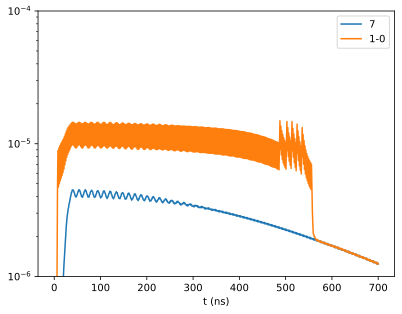

In [20]:
# qls = [7,4,24,2,12,22,10,20]
qls = [7]
for ql,pop_list in zip(qls,[lists[0][j] for j in qls]): 
# for ql,pop_list in enumerate(lists[0][:]): 
    plt.plot(tlist,pop_list,label = f"{ql}")
plt.plot(tlist,1-np.array(lists[0][0]),label = f"1-{0}")
plt.yscale('log')
plt.ylim(1e-6,1e-4)
plt.legend()
plt.legend()
plt.xlabel('t (ns)')

IndexError: list index out of range

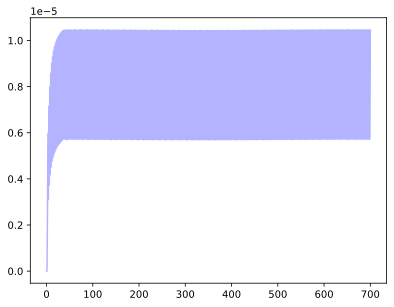

In [10]:
# qls = [1,4,0,10,24]
# qls = [10,24]
# for ql,pop_list in zip(qls,[lists[1][j] for j in qls]): 
# for ql,pop_list in enumerate(lists[1][:]): 
    # plt.plot(tlist,pop_list,label = f"{ql}",alpha = 0.3)
plt.plot(tlist,1-np.array(lists[1][1]),label = f"1-{1}",alpha = 0.3,color = 'blue')
plt.plot(tlist,np.array(lists[1][10])+np.array(lists[1][24]),label = f"{10}+{24}",alpha = 0.3,color = 'red')

plt.plot(tlist,lists[1][10],label = f"{10}",alpha = 0.3,color = 'green')
plt.plot(tlist,lists[1][24],label = f"{24}",alpha = 0.3,color = 'yellow')

plt.yscale('log')
plt.ylim(1e-11,3e-5)
plt.legend()
plt.xlabel('t (ns)')

In [ ]:
# qls = [2,4,14,24]
# for ql,pop_list in zip(qls,[lists[2][j] for j in qls]): 
# for ql,pop_list in enumerate(lists[2][:]): 
    # plt.plot(tlist,pop_list,label = f"{ql}")

plt.plot(tlist,1-np.array(lists[2][2]),label = f"1-{2}",color = 'blue',alpha = 0.3)
plt.plot(tlist,np.array(lists[2][24]),label = f"{24}",color = 'red',alpha = 0.3)

plt.yscale('log')
plt.legend()
plt.xlabel('t (ns)')

In [ ]:
interactive_heatmap(results[0], system.product_to_dressed, system.qbt.truncated_dim, system.osc.truncated_dim)

In [ ]:
interactive_heatmap(results[1], system.product_to_dressed, system.qbt.truncated_dim, system.osc.truncated_dim)

In [ ]:
interactive_heatmap(results[2], system.product_to_dressed, system.qbt.truncated_dim, system.osc.truncated_dim)

In [ ]:
evals = system.qbt.eigenvals(15)


import matplotlib.pyplot as plt

x_positions = range(len(evals))
plt.bar(x_positions[5:], evals[5:])
plt.axhline(y=evals[1] + system.w_d, color='r', linestyle='--', linewidth=2,label=r'$\omega_1 + \omega_osc$')
plt.axhline(y=evals[0] + system.w_d, color='g', linestyle='--', linewidth=2,label=r'$\omega_0 + \omega_osc$')
plt.axhline(y=evals[2] + system.w_d, color='black', linestyle='--', linewidth=2,label=r'$\omega_2 + \omega_osc$')
plt.legend()

In [ ]:
table = np.abs(system.qbt.matrixelement_table(operator='n_operator',evals_count = 15))
# table[0,7], [
#     [table[1,10],table[1,11]],
#     [table[2,10],table[2,11]]
# ]
print(f"detunning to 0-7 {abs(evals[7]-evals[0]-system.w_d)}, matrix_ele: {table[0,7]}")
print(f"detunning to 1-10 {abs(evals[10]-evals[1]-system.w_d)}, matrix_ele: {table[1,10]}")
print(f"detunning to 2-11 {abs(evals[11]-evals[2]-system.w_d)}, matrix_ele: {table[2,11]}")